見つかったファイル: ['results_px_0.0_Lx_22_Nd_1000_NT_14520.npz']
results_px_0.0_Lx_22_Nd_1000_NT_14520.npz → Lx=22, Nd=1000, NT=14520, px=0.0
results_px_0.0_Lx_22_Nd_1000_NT_14520.npz: Lx= 22


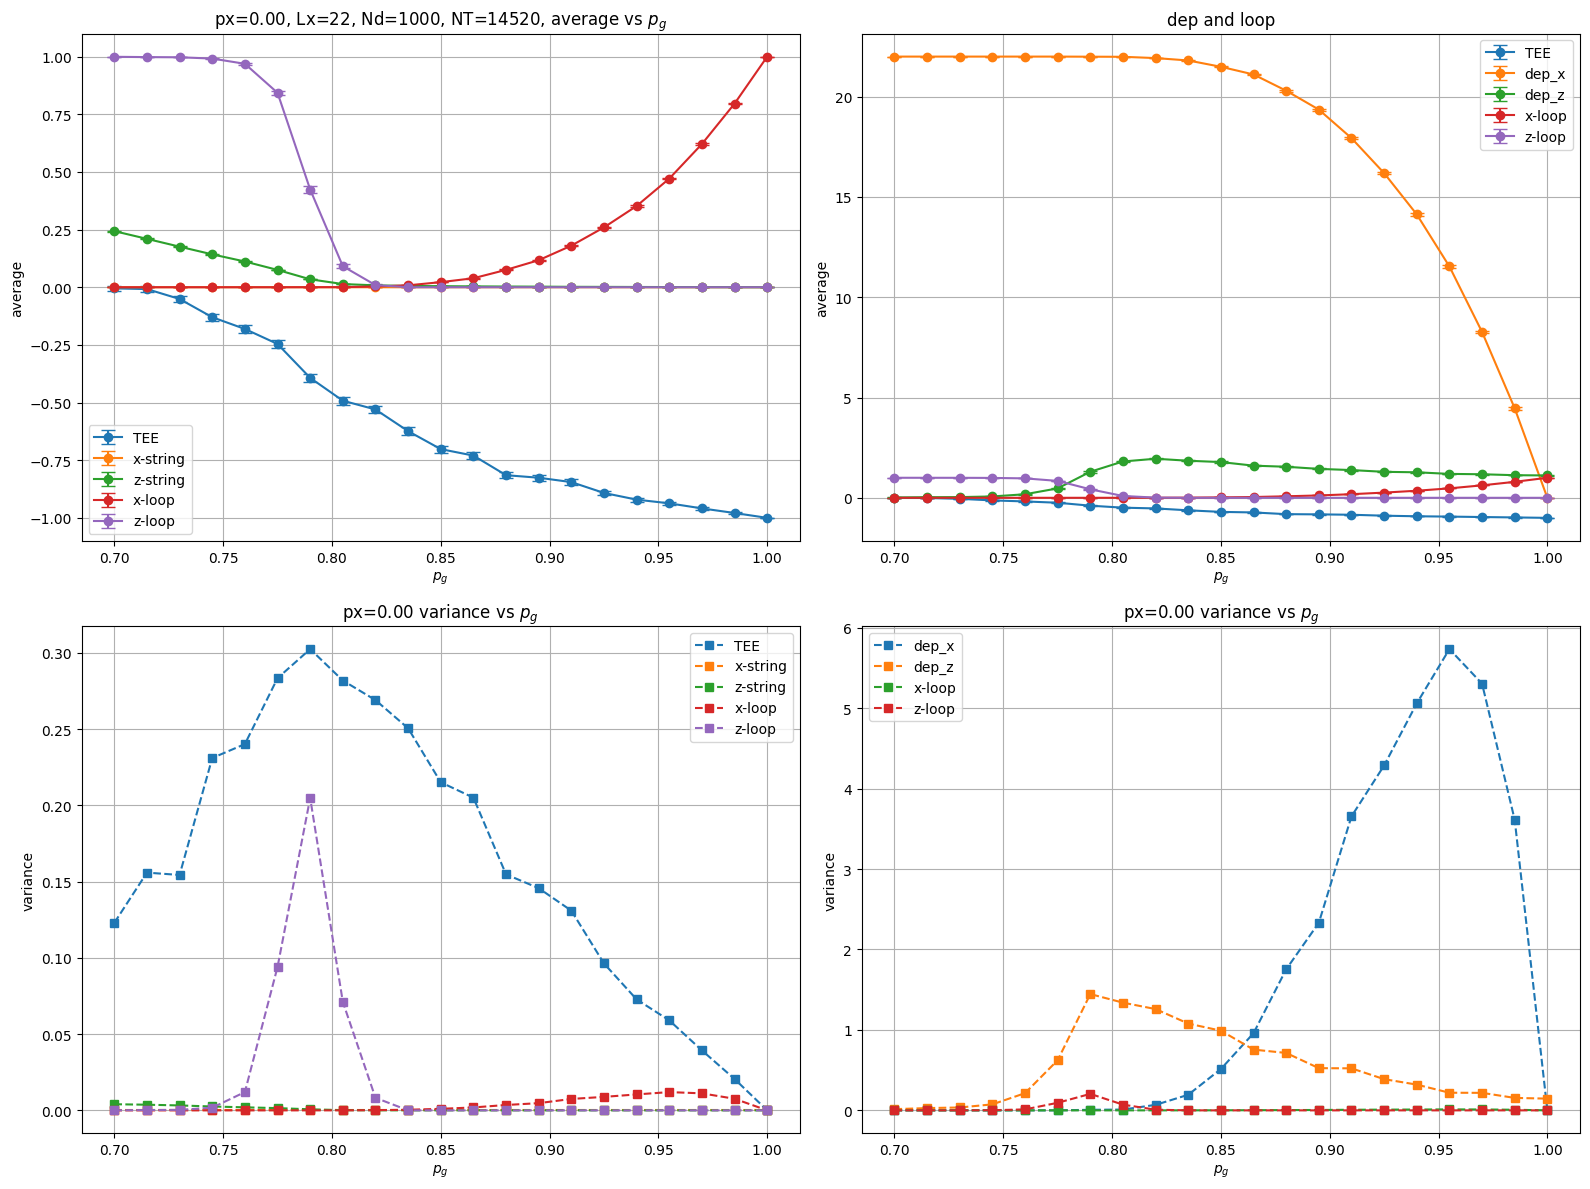

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# カラーマップ設定
cmap = plt.colormaps['gnuplot']

# ファイル読み込み
files = glob.glob("results_px_0.0_Lx_22_Nd_1000_NT_14520.npz")
print("見つかったファイル:", files)

for file in files:
    match = re.search(
        r"px_([0-9.]+)_Lx_(\d+)_Nd_(\d+)_NT_(\d+)", file
    )
    if match:
        px = float(match.group(1))
        Lx = int(match.group(2))
        Nd = int(match.group(3))
        NT = int(match.group(4))
        print(f"{file} → Lx={Lx}, Nd={Nd}, NT={NT}, px={px}")

# プロット用
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

for file in files:
    with np.load(file) as data:
        pg = data['pg']                      # ← 必ず最初に読み込む
        sort_idx = np.argsort(pg)           # ← 昇順インデックス
        pg = pg[sort_idx]                   # ← 並び替え
                
        TEE_ave = data['TEE_ave'][sort_idx]
        TEE_err = data['TEE_err'][sort_idx]
        TEE_var = data['TEE_var'][sort_idx]
        R2x_ave = data['R2x_ave'][sort_idx]
        R2x_err = data['R2x_err'][sort_idx]
        R2x_var = data['R2x_var'][sort_idx]
        R2z_ave = data['R2z_ave'][sort_idx]
        R2z_err = data['R2z_err'][sort_idx]
        R2z_var = data['R2z_var'][sort_idx]
        R2x_loop_ave = data['R2x_loop_ave'][sort_idx]
        R2x_loop_err = data['R2x_loop_err'][sort_idx]
        R2x_loop_var = data['R2x_loop_var'][sort_idx]
        R2z_loop_ave = data['R2z_loop_ave'][sort_idx]
        R2z_loop_err = data['R2z_loop_err'][sort_idx]
        R2z_loop_var = data['R2z_loop_var'][sort_idx]
        dep_x_ave = data['dep_x_ave'][sort_idx]
        dep_x_err = data['dep_x_err'][sort_idx]
        dep_x_var = data['dep_x_var'][sort_idx]
        dep_z_ave = data['dep_z_ave'][sort_idx]
        dep_z_err = data['dep_z_err'][sort_idx]
        dep_z_var = data['dep_z_var'][sort_idx]

    #label = f"px={px:.2f}"
    label =f"ee"
    # 左グラフ：TEEと相関の平均＋誤差
    ax[0,0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,0].errorbar(pg, R2x_ave, yerr=R2x_err, fmt='o-', capsize=5, label="x-string")
    ax[0,0].errorbar(pg, R2z_ave, yerr=R2z_err, fmt='o-', capsize=5, label="z-string")
    ax[0,0].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,0].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    # 右グラフ：分散
    ax[0,1].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,1].errorbar(pg, dep_x_ave, yerr=dep_x_err, fmt='o-', capsize=5, label="dep_x")
    ax[0,1].errorbar(pg, dep_z_ave, yerr=dep_z_err, fmt='o-', capsize=5, label="dep_z")
    ax[0,1].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,1].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    ax[1,0].plot(pg, TEE_var, 's--', label="TEE")    
    ax[1,0].plot(pg, R2x_var, 's--', label="x-string")
    ax[1,0].plot(pg, R2z_var, 's--', label="z-string")
    ax[1,0].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,0].plot(pg, R2z_loop_var, 's--', label="z-loop")
    
    ax[1,1].plot(pg, dep_x_var, 's--', label="dep_x")
    ax[1,1].plot(pg, dep_z_var, 's--', label="dep_z")
    ax[1,1].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,1].plot(pg, R2z_loop_var, 's--', label="z-loop")
    print(f"{file}: Lx= {Lx}")

# 描画設定
ax[0,0].set_xlabel('$p_g$')
ax[0,0].set_ylabel('average')
ax[0,0].set_title(f"px={px:.2f}, Lx={Lx}, Nd={Nd}, NT={NT}, average vs $p_g$")
ax[0,0].grid(True)
ax[0,0].legend()

ax[0,1].set_xlabel('$p_g$')
ax[0,1].set_ylabel('average')
ax[0,1].set_title("dep and loop")
ax[0,1].grid(True)
ax[0,1].legend()

ax[1,0].set_xlabel('$p_g$')
ax[1,0].set_ylabel('variance')
ax[1,0].set_title(f"px={px:.2f} variance vs $p_g$")
ax[1,0].grid(True)
ax[1,0].legend()

ax[1,1].set_xlabel('$p_g$')
ax[1,1].set_ylabel('variance')
ax[1,1].set_title(f"px={px:.2f} variance vs $p_g$")
ax[1,1].grid(True)
ax[1,1].legend()

plt.tight_layout()
plt.savefig(f"px_{px:.2f}_Lx_{Lx}_Nd_{Nd}_NT_{NT}_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [9]:
import numpy as np

data = np.load("results_px_0.0_Lx_22_Nd_1000_NT_14520.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var', 'R2x_ave', 'R2x_err', 'R2x_var', 'R2z_ave', 'R2z_err', 'R2z_var', 'R2x_loop_ave', 'R2x_loop_err', 'R2x_loop_var', 'R2z_loop_ave', 'R2z_loop_err', 'R2z_loop_var', 'dep_x_ave', 'dep_x_err', 'dep_x_var', 'dep_z_ave', 'dep_z_err', 'dep_z_var']


In [54]:
import numpy as np

data = np.load("results_px_0.0_Lx_10_Nd_1000_NT_3000.npz")
print(data['pg'])
print(data['R2x_ave'])
print(data['R2x_err'])
print(data['R2x_var'])
print(data['R2x_loop_ave'])
print(data['R2x_loop_err'])
print(data['R2x_loop_var'])
data.close()

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.22222222e-05 0.00000000e+00 0.00000000e+00]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.57056175e-05 0.00000000e+00 0.00000000e+00]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.46419753e-07 0.00000000e+00 0.00000000e+00]
[0.     0.     0.     0.     0.     0.     0.     0.     0.0211 0.4049
 1.    ]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.00168155 0.00510412 0.        ]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.00282479 0.02602599 0.        ]


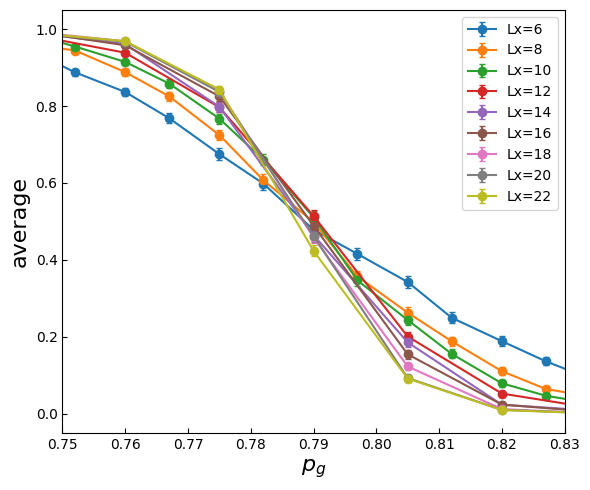

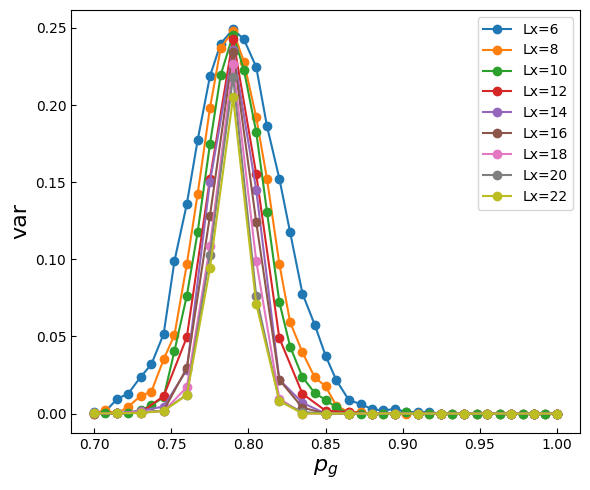

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# 読み込むファイルパターン
files = glob.glob("results_px_*_Lx_*_Nd_*_NT_*.npz")

data_by_L = {}

for fn in files:
    # ファイル名から Lx を抽出
    m = re.search(r"Lx_(\d+)", fn)
    if not m:
        continue
    Lx = int(m.group(1))

    # データを読み込む
    dat = np.load(fn)
    pg  = dat["pg"]
    ave = dat["R2z_loop_ave"]
    err = dat["R2z_loop_err"]
    var = dat["R2z_loop_var"]
    
    # サイズごとに格納
    data_by_L[Lx] = (pg, ave, err, var)


fig, ax = plt.subplots(figsize=(6,5))
for Lx, (pg, ave, err, var) in sorted(data_by_L.items()):
    ax.errorbar(pg, ave, yerr=err, fmt='o-', capsize=2, label=f"Lx={Lx}")

ax.set_xlabel(r"$p_g$", fontsize=16)
ax.set_ylabel("average", fontsize=16)
ax.set_xlim(0.75,0.83)
ax.grid(False)
ax.tick_params(direction="in", top=False, right=False)  # 左・下だけ内向き
ax.legend()
fig.tight_layout()
fig.savefig("px_0_zloop_ave.png", dpi=300, bbox_inches="tight")
plt.show()

# ===== プロット var =====
fig, ax = plt.subplots(figsize=(6,5))
for Lx, (pg, ave, err, var) in sorted(data_by_L.items()):
    ax.plot(pg, var, 'o-', label=f"Lx={Lx}")

ax.set_xlabel(r"$p_g$", fontsize=16)
ax.set_ylabel("var", fontsize=16)
ax.grid(False)
ax.tick_params(direction="in", top=False, right=False)
ax.legend()
fig.tight_layout()
fig.savefig("px_0_zloop_var.png", dpi=300, bbox_inches="tight")
plt.show()

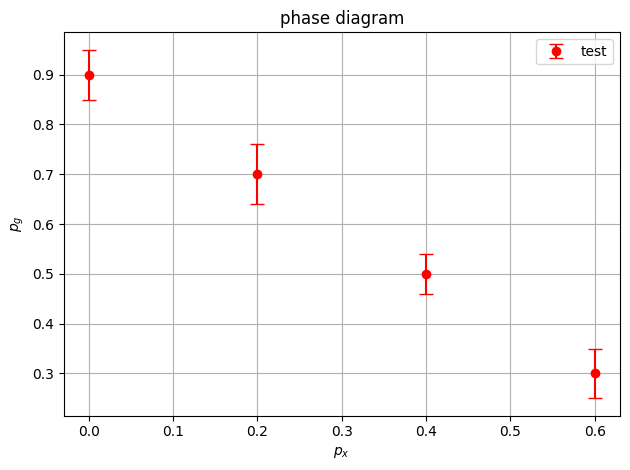

In [71]:
px = np.array([0.0, 0.2, 0.4, 0.6])
pg = np.array([0.9, 0.7, 0.5, 0.3])
pg_err = np.array([0.05, 0.06, 0.04, 0.05])  # 幅（例）

plt.errorbar(px, pg, yerr=pg_err, fmt='o', color='red', capsize=5, label="test")
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_g$')
plt.title("phase diagram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

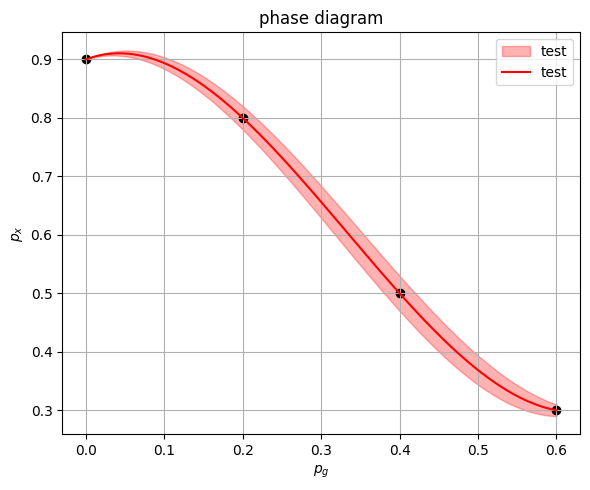

In [6]:
from scipy.interpolate import make_interp_spline

px = np.array([0.0, 0.2, 0.4, 0.6])
pg = np.array([0.9, 0.8, 0.5, 0.3])
pg_err = np.array([0.00, 0.02, 0.03, 0.01])  # 幅（例）

# 中央点と誤差
pg_upper = pg + pg_err
pg_lower = pg - pg_err

# 補間（なめらかな曲線に）
px_smooth = np.linspace(px.min(), px.max(), 300)
spline_mid = make_interp_spline(px, pg, k=3)
spline_upper = make_interp_spline(px, pg_upper, k=3)
spline_lower = make_interp_spline(px, pg_lower, k=3)

pg_smooth = spline_mid(px_smooth)
pg_smooth_upper = spline_upper(px_smooth)
pg_smooth_lower = spline_lower(px_smooth)

# 描画
plt.figure(figsize=(6, 5))
plt.fill_between(px_smooth, pg_smooth_lower, pg_smooth_upper, color='red', alpha=0.3, label='test')
plt.plot(px_smooth, pg_smooth, color='red', label='test')
plt.scatter(px, pg, color='black')
plt.xlabel(r'$p_g$')
plt.ylabel(r'$p_x$')
plt.title("phase diagram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()